     DATEPRD WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2014-04-07  NO 15/9-F-1 C                7405         15/9-F-1 C   
1 2014-04-08  NO 15/9-F-1 C                7405         15/9-F-1 C   
2 2014-04-09  NO 15/9-F-1 C                7405         15/9-F-1 C   
3 2014-04-10  NO 15/9-F-1 C                7405         15/9-F-1 C   
4 2014-04-11  NO 15/9-F-1 C                7405         15/9-F-1 C   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  AVG_CHOKE_UOM  AVG_WHP_P  \
0            0.0                0.00000  ...              %    0.0

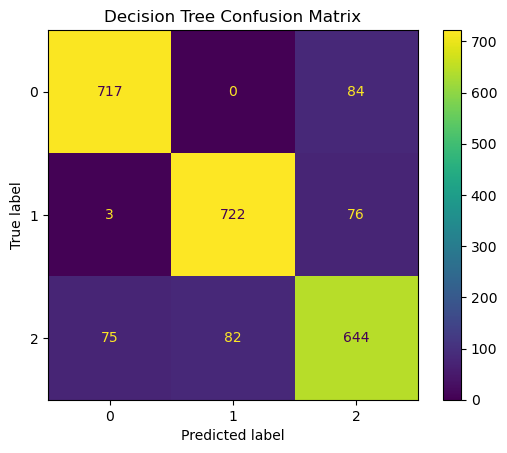


========== RANDOM FOREST ==========
Accuracy : 0.9542238868081565
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       801
           1       0.96      0.96      0.96       801
           2       0.94      0.92      0.93       801

    accuracy                           0.95      2403
   macro avg       0.95      0.95      0.95      2403
weighted avg       0.95      0.95      0.95      2403



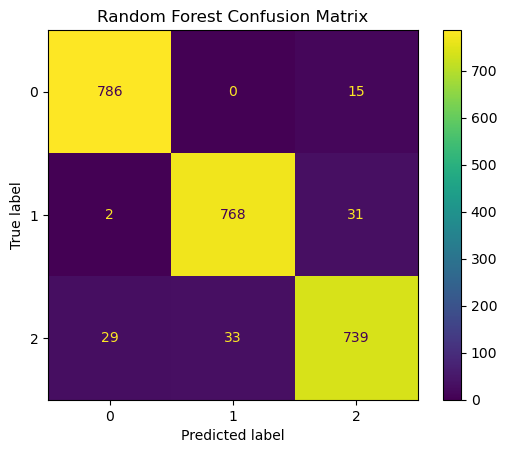

           Model  Accuracy
0  Decision Tree  0.866833
1  Random Forest  0.954224


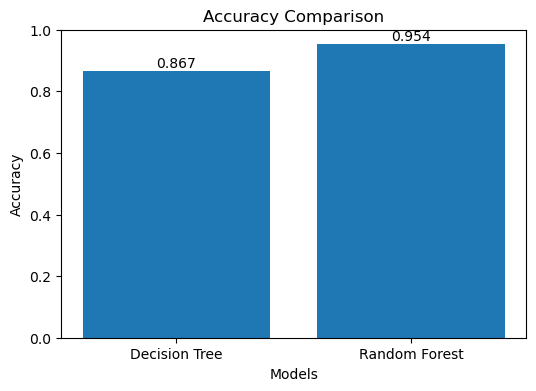


Conclusion : Random Forest performed better than Decision Tree.


In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_excel(
    r"C:\Users\EileneAnnaKuriakose\Desktop\Volve production data.xlsx",
    sheet_name="Daily Production Data"
)

# ==========================================
# VIEW DATASET
# ==========================================

print(df.head())
print("\nShape :", df.shape)
print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# DATA CLEANING
# ==========================================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Keep only producing wells
df = df[df["BORE_OIL_VOL"] > 0]

# Select useful columns
df = df[
    [
        "ON_STREAM_HRS",
        "AVG_DOWNHOLE_PRESSURE",
        "AVG_DOWNHOLE_TEMPERATURE",
        "AVG_DP_TUBING",
        "AVG_ANNULUS_PRESS",
        "AVG_CHOKE_SIZE_P",
        "AVG_WHP_P",
        "BORE_OIL_VOL",
    ]
]

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Reset index
df.reset_index(drop=True, inplace=True)

# ==========================================
# CREATE TARGET VARIABLE
# ==========================================

df["Production_Class"] = pd.qcut(
    df["BORE_OIL_VOL"],
    q=3,
    labels=["Low", "Medium", "High"]
)

encoder = LabelEncoder()

df["Production_Class"] = encoder.fit_transform(df["Production_Class"])

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop(["BORE_OIL_VOL", "Production_Class"], axis=1)

y = df["Production_Class"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ==========================================
# DECISION TREE
# ==========================================

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\n========== DECISION TREE ==========")
print("Accuracy :", dt_accuracy)
print(classification_report(y_test, dt_pred))

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n========== RANDOM FOREST ==========")
print("Accuracy :", rf_accuracy)
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================
# ACCURACY COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

print(comparison)

plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(comparison["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.ylim(0, 1)

plt.show()

# ==========================================
# CONCLUSION
# ==========================================

if rf_accuracy > dt_accuracy:
    print("\nConclusion : Random Forest performed better than Decision Tree.")
elif dt_accuracy > rf_accuracy:
    print("\nConclusion : Decision Tree performed better than Random Forest.")
else:
    print("\nConclusion : Both models achieved the same accuracy.")